# Master Fraud Detection Lab: From Basics to ML Evaluation

Welcome to the comprehensive Fraud Detection Lab! This lab is designed to take you from raw data to building and evaluating advanced AI models.

**Objective**: Learn how to process, explore, clean, and use Machine Learning to predict fraudulent transactions with business impact analysis.

---

# Part 1: Basic Data Processing
Getting started with loading and understanding your data.

## Section 1: Introduction and Data Loading
### Concept: DataFrames
In Python, the `pandas` library uses a structure called a **DataFrame**. Think of it as a super-powered Excel spreadsheet inside your code. 

- `pd.read_csv()`: This function opens a CSV file and converts it into a DataFrame.
- `df.head()`: This shows you the first 5 rows so you can quickly see if the data loaded correctly.

In [1]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('fraud_data.csv')

# See the first few rows
print("Sample Data:")
print(df.head())

Sample Data:
   Transaction_ID    Amount Category   Location  Is_Fraud
0            1001  25000.00   Retail       Pune         0
1            1002   3060.12   Retail      Delhi         0
2            1003   1366.75  Grocery     Mumbai         0
3            1004    962.94   Online  Bangalore         0
4            1005    219.62   Dining     Mumbai         0


## Section 2: Exploratory Data Analysis (EDA)
### Concept: `df.describe()` - The Statistical Snapshot
What does `df.describe()` tell us? It provides a summary of all numerical columns in your dataset:
1. **count**: Number of non-empty rows.
2. **mean**: The average value.
3. **std**: Standard Deviation.
4. **min/max**: The smallest and largest values.
5. **25%, 50%, 75%**: Percentiles (50% is the Median).

In [3]:
print("Data Information : ")
print(df.info())

Data Information : 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160 entries, 0 to 159
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Transaction_ID  160 non-null    int64  
 1   Amount          154 non-null    float64
 2   Category        160 non-null    object 
 3   Location        142 non-null    object 
 4   Is_Fraud        160 non-null    int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 6.4+ KB
None


In [5]:
print("Basic Statistics Table:")
print(df.describe())


Basic Statistics Table:
       Transaction_ID        Amount    Is_Fraud
count      160.000000    154.000000  160.000000
mean      1080.500000   1516.156494    0.068750
std         46.332134   3228.222099    0.253823
min       1001.000000     55.540000    0.000000
25%       1040.750000    342.410000    0.000000
50%       1080.500000    762.660000    0.000000
75%       1120.250000   1676.097500    0.000000
max       1160.000000  30000.000000    1.000000


## Section 3: Data Filtering and Insights
### Concept: Boolean Indexing
Filtering lets us ask questions like "Show me only the fraud cases."

- `df[df['Is_Fraud'] == 1]`: This "filters" the table to keep only rows where the fraud flag is true.
- `value_counts()`: Tells us how many times each unique value appears.

In [7]:
# Filter for fraud cases
fraud_only = df[df['Is_Fraud'] == 1]
print(f"Total Fraud Cases Found: {len(fraud_only)}")

Total Fraud Cases Found: 11


## Section 4: Data Visualization
### Concept: Visual Insight
Charts make patterns obvious that numbers might hide.
- **Pie Charts**: Best for showing "parts of a whole" (e.g., % of Fraud vs Normal).

Class Distribution:
Is_Fraud
0    0.93125
1    0.06875
Name: proportion, dtype: float64


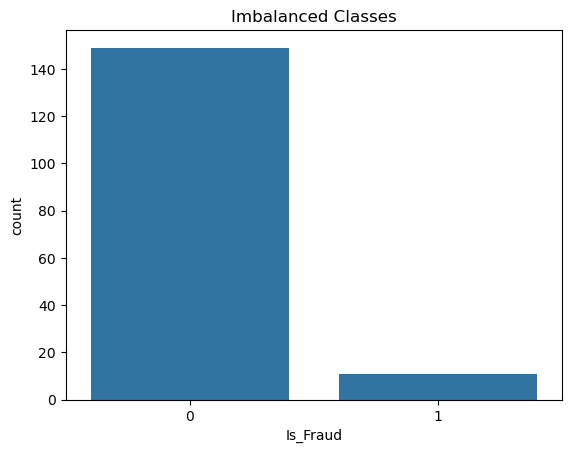

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
print("Class Distribution:")
print(df['Is_Fraud'].value_counts(normalize=True))

sns.countplot(x='Is_Fraud', data=df)
plt.title('Imbalanced Classes')
plt.show()

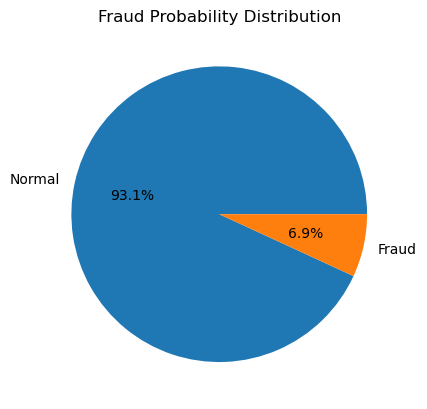

In [11]:
# Simple Pie Chart for Fraud
df['Is_Fraud'].value_counts().plot(kind='pie', labels=['Normal', 'Fraud'], autopct='%1.1f%%')
plt.title('Fraud Probability Distribution')
plt.ylabel('')
plt.show()

---
# Part 2: Advanced Data Cleaning & Prep
Preparing your data for professional-grade analysis.

## Section 5: Handling Missing Data
### Concept: `isnull()` and `fillna()`
Filling missing values with the **Median** is a safe way to handle gaps without distorting the data too much.

In [13]:
# Check missing values
print("Missing before handling:")
print(df.isnull().sum())

Missing before handling:
Transaction_ID     0
Amount             6
Category           0
Location          18
Is_Fraud           0
dtype: int64


Sum of amounts by category:
Category
Dining     30884.99
Grocery    40826.37
Online     28770.01
Retail     73733.46
Travel     59273.27
Name: Amount, dtype: float64


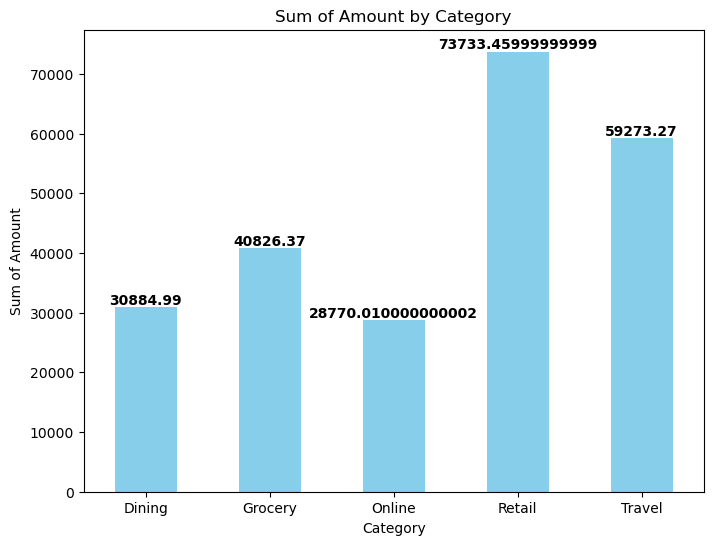

In [15]:
# 2. Group by 'Category' and sum the 'Amount'
# The result is a pandas Series with 'Category' as the index
sum_by_category = df.groupby('Category')['Amount'].sum()

print("Sum of amounts by category:")
print(sum_by_category)

# 3. Plot the data using matplotlib
plt.figure(figsize=(8, 6))
sum_by_category.plot(kind='bar', color='skyblue')

# Add labels and title
plt.title('Sum of Amount by Category')
plt.xlabel('Category')
plt.ylabel('Sum of Amount')
plt.xticks(rotation=0) # Keep x-axis labels horizontal for readability

# Optional: Add value labels on top of the bars
for index, value in enumerate(sum_by_category):
    plt.text(index, value + 10, str(value), ha='center', va='bottom', fontweight='bold')

# Display the chart
plt.show()

In [17]:
# Fixing: Fill missing Amount with median
#df['Amount'] = df['Amount'].fillna(df['Amount'].median())

# Fill NaN in 'Amount' with the median of its 'Category'
df['Amount'] = df.groupby('Category')['Amount'].transform(lambda x: x.fillna(x.median()))

In [19]:

# Fixing: Fill missing Location with 'Unknown'
df['Location'] = df['Location'].fillna('Unknown')

In [21]:
# Check missing values
print("Missing after handling:")
print(df.isnull().sum())

Missing after handling:
Transaction_ID    0
Amount            0
Category          0
Location          0
Is_Fraud          0
dtype: int64


## Section 6: Outlier Detection
### Concept: The Box Plot
A **Box Plot** visualizes the distribution and spots extreme values like a $30,000 transaction.

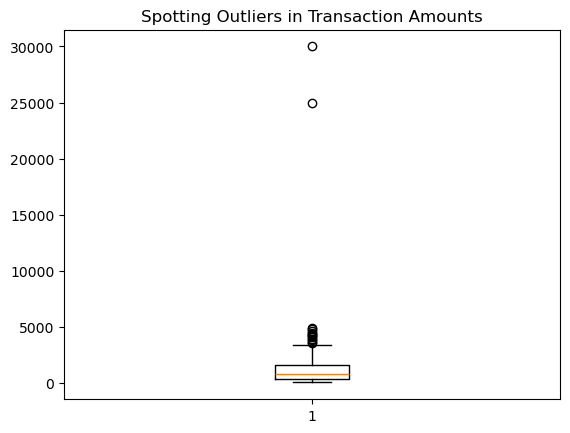

In [23]:
plt.boxplot(df['Amount'])
plt.title('Spotting Outliers in Transaction Amounts')
plt.show()

## Section 7: Addressing Outliers and Skew
### Concept: Skewness and Capping
- **Capping (`clip`)**: We "cap" outliers at a maximum value so they don't break our models.

In [25]:
# Capping: Removing the influence of outliers by setting a max limit
df['Amount_Cleaned'] = df['Amount'].clip(upper=5000)

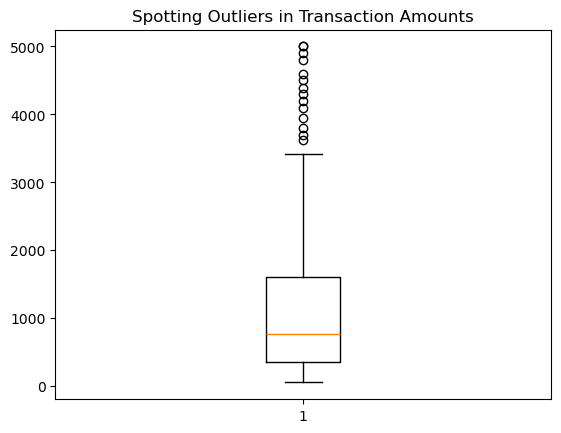

In [27]:
plt.boxplot(df['Amount_Cleaned'])
plt.title('Spotting Outliers in Transaction Amounts')
plt.show()

## Section 8: Data Standardization
### Concept: The Z-Score
Computers work better when numbers are on a similar scale.
- **Formula**: `(Value - Mean) / Standard Deviation`

In [29]:
mean = df['Amount_Cleaned'].mean()
std = df['Amount_Cleaned'].std()

# Standardize (Z-score)
df['Amount_Scaled'] = (df['Amount_Cleaned'] - mean) / std
print("Standardization Complete.")
print(df.head())

Standardization Complete.
   Transaction_ID    Amount Category   Location  Is_Fraud  Amount_Cleaned  \
0            1001  25000.00   Retail       Pune         0         5000.00   
1            1002   3060.12   Retail      Delhi         0         3060.12   
2            1003   1366.75  Grocery     Mumbai         0         1366.75   
3            1004    962.94   Online  Bangalore         0          962.94   
4            1005    219.62   Dining     Mumbai         0          219.62   

   Amount_Scaled  
0       3.060331  
1       1.494877  
2       0.128352  
3      -0.197516  
4      -0.797364  


---
# Part 3: ML Model Implementation and Evaluation
Now we move to building models and evaluating them individually.

## Section 9: Data Preparation for ML
### Concept: Features, Labels, and Stratified Splitting
- **Encoding**: Converting text categories into numbers.
- **Stratified Split**: Ensures that fraud cases are present in both Training and Testing sets.

In [31]:
# 1. Convert Category to numbers (One-Hot Encoding)
df_ml = pd.get_dummies(df, columns=['Category'], drop_first=True)
print(df_ml.head())


   Transaction_ID    Amount   Location  Is_Fraud  Amount_Cleaned  \
0            1001  25000.00       Pune         0         5000.00   
1            1002   3060.12      Delhi         0         3060.12   
2            1003   1366.75     Mumbai         0         1366.75   
3            1004    962.94  Bangalore         0          962.94   
4            1005    219.62     Mumbai         0          219.62   

   Amount_Scaled  Category_Grocery  Category_Online  Category_Retail  \
0       3.060331             False            False             True   
1       1.494877             False            False             True   
2       0.128352              True            False            False   
3      -0.197516             False             True            False   
4      -0.797364             False            False            False   

   Category_Travel  
0            False  
1            False  
2            False  
3            False  
4            False  


In [33]:
# 2. Select Features and Target
features = ['Amount_Scaled'] + [col for col in df_ml.columns if 'Category_' in col]
X = df_ml[features]
y = df_ml['Is_Fraud']
print(X.head())


   Amount_Scaled  Category_Grocery  Category_Online  Category_Retail  \
0       3.060331             False            False             True   
1       1.494877             False            False             True   
2       0.128352              True            False            False   
3      -0.197516             False             True            False   
4      -0.797364             False            False            False   

   Category_Travel  
0            False  
1            False  
2            False  
3            False  
4            False  


In [35]:
from sklearn.model_selection import train_test_split
# 3. Split into Train and Test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Dictionary to store results for comparison
results = {}

print(f"Training size: {X_train.shape[0]}, Testing size: {X_test.shape[0]}")

Training size: 128, Testing size: 32


## Section 10: Logistic Regression
### Concept: The Probabilistic Baseline
Logistic Regression is a foundational classification model. Despite its name, it's used for **classification**, not regression. It estimates the probability that a data point belongs to a particular class (e.g., Fraud or Normal) using the **Sigmoid function**.

#### Key Functions to Understand:
1. **`predict()`**: This function returns a direct class label (0 or 1). By default, it uses a 0.5 threshold (if probability > 0.5, it's class 1).
2. **`predict_proba()`**: This returns the raw probabilities (e.g., [0.98, 0.02]). The second value is the probability of the transaction being **Fraud**. This is crucial for fraud detection because we often want to flag transactions even if the model is only 30% sure!

In [37]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

# Let's see the raw probabilities
y_prob = log_model.predict_proba(X_test)[:, 1]
y_pred = log_model.predict(X_test)

# Update: Logistic Regression Threshold
# We use a lower threshold (0.3) to catch more fraud, even if we get some false alarms.
CUSTOM_THRESHOLD = 0.3
y_pred_custom = (y_prob >= CUSTOM_THRESHOLD).astype(int)

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    confusion_matrix, ConfusionMatrixDisplay, 
    precision_recall_curve, average_precision_score
)

results["Logistic Regression"] = {
    "Accuracy": accuracy_score(y_test, y_pred_custom),
    "Precision": precision_score(y_test, y_pred_custom, zero_division=0),
    "Recall": recall_score(y_test, y_pred_custom, zero_division=0),
    "Probabilities": y_prob,
    "Predictions": y_pred_custom
}

print(f"Logistic Regression metrics calculated with threshold: {CUSTOM_THRESHOLD}")

Logistic Regression metrics calculated with threshold: 0.3


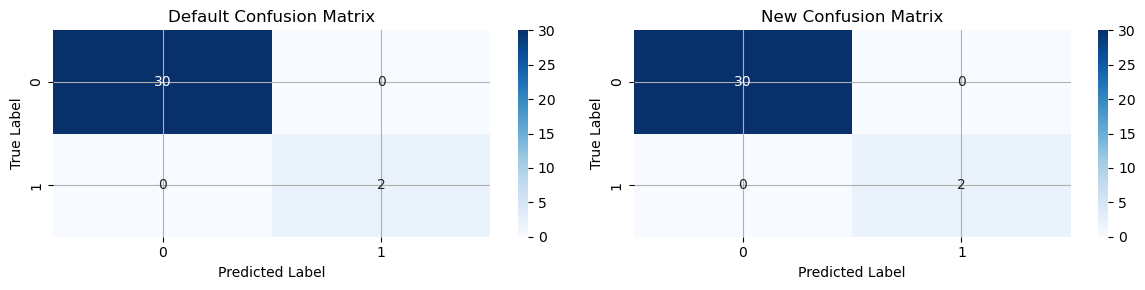

In [39]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)
y_prob_new = log_model.predict_proba(X_test)[:, 1]



# Set the custom threshold (e.g., 0.3)
new_threshold = 0.3
# Generate predictions with the new threshold
y_pred_new = (y_prob_new >= new_threshold).astype(int)

cm  = confusion_matrix(y_test, y_pred)
cm1 = confusion_matrix(y_test, y_pred_new)

# Create a figure and a set of subplots arranged in 1 row and 2 columns
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 3)) #

# Plot data on the first axis (left chart)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_title('Default Confusion Matrix')
ax1.set_xlabel('Predicted Label')
ax1.set_ylabel('True Label')
ax1.grid(True) #

# Plot data on the second axis (right chart)
#ax2.plot(x, y2, '.-', color='red')
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', ax=ax2)
ax2.set_title('New Confusion Matrix')
ax2.set_xlabel('Predicted Label')
ax2.set_ylabel('True Label')
ax2.grid(True)

# Adjust layout to prevent titles and labels from overlapping
plt.tight_layout()

# Display the combined figure
plt.show()

## Section 11: Random Forest
### Concept: Decision Trees Ensemble
Imagine you're trying to identify a mystery fruit. One person might guess based on color, another on size, and another on texture. A **Random Forest** is like asking 100 people (Trees) and taking a majority vote! This "Wisdom of the Crowd" makes it much more accurate than a single person (Tree).

**Example**: 
- Tree 1: "It's red, so it's an Apple."
- Tree 2: "It has a stem, so it's a Cherry."
- Tree 3: "It's crunchy, so it's an Apple."
- **Result**: The Forest votes "Apple" (2 vs 1).

#### Understanding Key Parameters:
When building a Random Forest, we can tune several "knobs" to improve performance:
1. **`n_estimators=100`**: This is the number of trees in the forest. Generally, more trees make the model more robust, but also slower to train. 100 is a good baseline.
2. **`random_state=42`**: This ensures that every time you run the code, you get the same result. The number '42' is just a common choice (a wink to *Hitchhiker's Guide to the Galaxy*).
3. **`max_depth`**: Limits how deep each tree can grow. If trees are too deep, they might "overfit" (memorize noise in the data). If too shallow, they might miss patterns.
4. **`min_samples_split`**: The minimum number of data points required to split a node. Higher values prevent the model from learning too many specific rules about single data points.

In [41]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

results["Random Forest"] = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "Probabilities": y_prob,
    "Predictions": y_pred
}

print("Random Forest metrics calculated.")

Random Forest metrics calculated.


## Section 12: Support Vector Machine (SVM)
### Concept: Finding the Maximum Margin Boundary
SVM looks for the best "boundary" (hyperplane) that separates different classes with as much space (margin) as possible. 

#### Key Concepts:
- **Support Vectors**: These are the data points closest to the boundary. They are the most "difficult" cases that define where the line is drawn.
- **The Margin**: The distance between the boundary and the support vectors. SVM tries to maximize this to increase confidence.
- **Kernel Trick**: If data isn't separable by a straight line, SVM can project it into a higher dimension (like lifting points off a 2D paper) to find a clear division.

**Pros**: Very effective in high-dimensional spaces.
**Cons**: Can be slow on very large datasets.

In [43]:

from sklearn.svm import SVC
svm_model = SVC(probability=True, kernel='linear')
svm_model.fit(X_train, y_train)
y_pred = svm_model.predict(X_test)
y_prob = svm_model.predict_proba(X_test)[:, 1]

results["SVM (Vector)"] = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "Probabilities": y_prob,
    "Predictions": y_pred
}

print("SVM metrics calculated.")

SVM metrics calculated.


## Section 13: k-Nearest Neighbors (k-NN)
### Concept: Similarity Based Classification
k-NN is often called a **"Lazy Learner"** because it doesn't really learn a model. Instead, it just remembers all the training data. When a new transaction comes in, it looks at the 'k' closest transactions. If most of those neighbors were fraud, the new one is flagged too.

#### Important Considerations:
- **Choosing 'k'**: A small 'k' (like 1) can be noisy. A large 'k' might be too smooth. '5' is a common starting point.
- **Feature Scaling**: Because k-NN uses distance (like the distance between points on a map), features MUST be scaled. If one feature is $0-$1 (Fraud flag) and another is $1,000,000 (Amount), the Amount will dominate the distance calculation!

In [45]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred = knn_model.predict(X_test)
y_prob = knn_model.predict_proba(X_test)[:, 1]

results["k-NN"] = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "Probabilities": y_prob,
    "Predictions": y_pred
}

print("k-NN metrics calculated.")

k-NN metrics calculated.


## Section 14: Precision-Recall Curves
### Concept: The Accuracy Trade-off
The **PR Curve** helps us visualize how Precision and Recall change as we adjust the model's sensitivity.

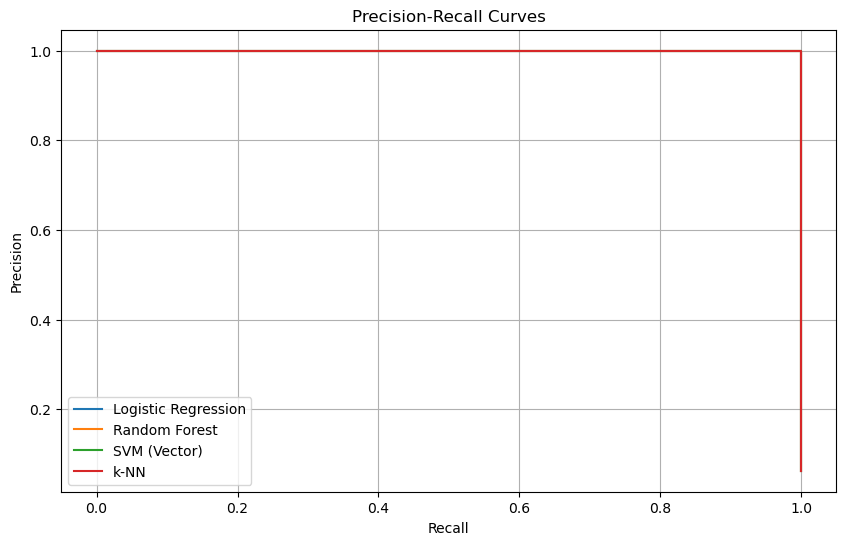

In [47]:
plt.figure(figsize=(10, 6))
for name, data in results.items():
    precision, recall, _ = precision_recall_curve(y_test, data['Probabilities'])
    plt.plot(recall, precision, label=f"{name}")

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves')
plt.legend()
plt.grid(True)
plt.show()

## Section 15: Optimal Threshold Selection
### Concept: F1-Score Balancing
Wait! we don't always use the default 50% cutoff. We use the **F1-score** to find a threshold that provides the best balance.

In [49]:
def find_best_threshold(y_true, y_probs):
    if y_true.sum() == 0: return 0.5
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_probs)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
    best_idx = np.argmax(f1_scores)
    return thresholds[best_idx] if best_idx < len(thresholds) else 0.5

print("Recommended Optimal Thresholds:")
for name, data in results.items():
    best_t = find_best_threshold(y_test, data['Probabilities'])
    print(f"{name}: {best_t:.4f}")

Recommended Optimal Thresholds:
Logistic Regression: 0.8447
Random Forest: 0.7400
SVM (Vector): 0.7393
k-NN: 0.8000


## Section 16: Final Business Cost Comparison
### Table of Performance and Cost
In business, we care about dollars saved.

In [51]:
INVESTIGATION_COST = 10
AVG_FRAUD_LOSS = 500

header = f"{'Model':<20} | {'Acc':<6} | {'Prec':<6} | {'Recall':<6} | {'Cost':<6}"
print(header)
print("-" * len(header))

for name, data in results.items():
    cm = confusion_matrix(y_test, data['Predictions'])
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (cm[0,0], 0, 0, 0)
    total_cost = (fp * INVESTIGATION_COST) + (fn * AVG_FRAUD_LOSS)
    print(f"{name:<20} | {data['Accuracy']:>6.1%} | {data['Precision']:>6.1%} | {data['Recall']:>6.1%} | ${total_cost:<6}")

Model                | Acc    | Prec   | Recall | Cost  
--------------------------------------------------------
Logistic Regression  | 100.0% | 100.0% | 100.0% | $0     
Random Forest        | 100.0% | 100.0% | 100.0% | $0     
SVM (Vector)         | 100.0% | 100.0% | 100.0% | $0     
k-NN                 | 100.0% | 100.0% | 100.0% | $0     
